In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from PIL import Image, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Set up the classification

In [3]:
train_mean = 0.606
train_std = 0.1944

In [4]:
# for corupted files


class SafeImageFolder(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.transform = transform
        # filter out corrupted images
        self.valid_indices = []
        for i in range(len(self.dataset)):
            path, _ = self.dataset.samples[i]
            try:
                with open(path, "rb") as f:
                    Image.open(f).verify()
                self.valid_indices.append(i)
            except (UnidentifiedImageError, OSError):
                print(f"Skipping corrupted image: {path}")

        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.targets = [self.dataset.targets[i] for i in self.valid_indices]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        return self.dataset[self.valid_indices[idx]]

In [5]:
# Transformations
train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),  # 3 kanalen voor ResNet50!
        transforms.Resize((128, 128)),
        transforms.RandomRotation(degrees=10, fill=0),
        transforms.RandomAffine(
            degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=0
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean, train_mean, train_mean],
            std=[train_std, train_std, train_std],
        ),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[train_mean, train_mean, train_mean],
            std=[train_std, train_std, train_std],
        ),
    ]
)

# Loading maps
train_dataset = SafeImageFolder(
    root="data_project_gray/train", transform=train_transform
)
val_dataset = SafeImageFolder(
    root="data_project_gray/val", transform=val_test_transform
)
test_dataset = SafeImageFolder(
    root="data_project_gray/test", transform=val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Skipping corrupted image: data_project_gray/train\0\9184495L.png
Skipping corrupted image: data_project_gray/val\1\9294761L.png


In [7]:
criterion = nn.BCEWithLogitsLoss()


# From Task 2
def calculate_metrics(loader, model, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)

            y = y.to(device).float().unsqueeze(1)  # Make sure labels have good size

            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_probs),
    }


print("Setup compleet!")

Setup compleet!


## Set up the base model:

In [6]:
# Instantiation of the model
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

# Freeze all layers in the base model
for param in model.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\bbgam/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


In [7]:
num_features = model.fc.in_features

model.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))

In [8]:
model = model.to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
# For checking
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nAmount of trainable parameters: {trainable_params:,}")


Amount of trainable parameters: 2,049


## Training model

In [10]:
import matplotlib.pyplot as plt

EPOCHS = 30
LEARNING_RATE = 1e-3
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": [],
}

Epoch 01/30 | Train Loss: 0.6448 | Val Loss: 0.6736 | Acc: 0.608 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUC: 0.574
Epoch 02/30 | Train Loss: 0.6227 | Val Loss: 0.6376 | Acc: 0.608 | Prec: 0.000 | Rec: 0.000 | F1: 0.000 | AUC: 0.705
Epoch 03/30 | Train Loss: 0.5920 | Val Loss: 0.6240 | Acc: 0.639 | Prec: 0.857 | Rec: 0.097 | F1: 0.174 | AUC: 0.725
Epoch 04/30 | Train Loss: 0.5821 | Val Loss: 0.6076 | Acc: 0.652 | Prec: 0.889 | Rec: 0.129 | F1: 0.225 | AUC: 0.743
Epoch 05/30 | Train Loss: 0.5561 | Val Loss: 0.6025 | Acc: 0.671 | Prec: 0.857 | Rec: 0.194 | F1: 0.316 | AUC: 0.739
Epoch 06/30 | Train Loss: 0.5701 | Val Loss: 0.6004 | Acc: 0.684 | Prec: 0.875 | Rec: 0.226 | F1: 0.359 | AUC: 0.751
Epoch 07/30 | Train Loss: 0.5512 | Val Loss: 0.5925 | Acc: 0.677 | Prec: 0.923 | Rec: 0.194 | F1: 0.320 | AUC: 0.761
Epoch 08/30 | Train Loss: 0.5187 | Val Loss: 0.5771 | Acc: 0.684 | Prec: 0.833 | Rec: 0.242 | F1: 0.375 | AUC: 0.778
Epoch 09/30 | Train Loss: 0.5331 | Val Loss: 0.5822 | Acc: 0.677

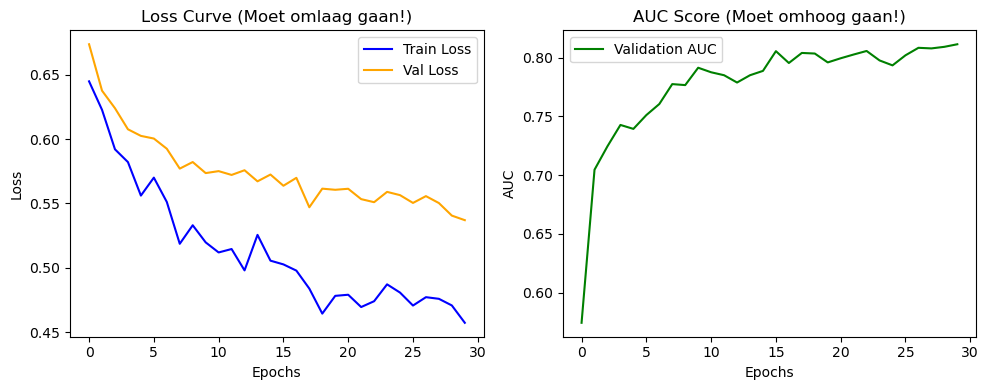

In [11]:
# Mostly from Task 2
for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss = 0.0

    for X, y in train_loader:
        X = X.to(device)
        y = (
            y.to(device).float().unsqueeze(1)
        )  # unsqueeze: make sure it has the right size

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y)

    train_loss /= len(train_dataset)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device).float().unsqueeze(1)

            logits = model(X)
            loss = criterion(logits, y)
            val_loss += loss.item() * len(y)

    val_loss /= len(val_dataset)

    metrics = calculate_metrics(val_loader, model)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(metrics["accuracy"])
    history["val_precision"].append(metrics["precision"])
    history["val_recall"].append(metrics["recall"])
    history["val_f1"].append(metrics["f1"])
    history["val_auc"].append(metrics["auc"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc: {metrics['accuracy']:.3f} | Prec: {metrics['precision']:.3f} | "
        f"Rec: {metrics['recall']:.3f} | F1: {metrics['f1']:.3f} | "
        f"AUC: {metrics['auc']:.3f}"
    )


plt.figure(figsize=(10, 4))

# Grafiek 1: Loss (Fouten)
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", color="blue")
plt.plot(history["val_loss"], label="Val Loss", color="orange")
plt.title("Loss Curve (Moet omlaag gaan!)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Grafiek 2: Performance (AUC)
plt.subplot(1, 2, 2)
plt.plot(history["val_auc"], label="Validation AUC", color="green")
plt.title("AUC Score (Moet omhoog gaan!)")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()

plt.tight_layout()
plt.show()

## Training model on full dataset

In [15]:
val_dataset_for_train = SafeImageFolder(
    root="data_project_gray/val", transform=train_transform
)
full_train_dataset = ConcatDataset([train_dataset, val_dataset_for_train])
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

Skipping corrupted image: data_project_gray/val\1\9294761L.png


In [16]:
weights = models.ResNet50_Weights.IMAGENET1K_V2
model_final = models.resnet50(weights=weights)

for param in model_final.parameters():
    param.requires_grad = False

num_features = model_final.fc.in_features
model_final.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))
model_final = model_final.to(device)

Epoch 01/30 | Train Loss: 0.6605
Epoch 02/30 | Train Loss: 0.6182
Epoch 03/30 | Train Loss: 0.5920
Epoch 04/30 | Train Loss: 0.5751
Epoch 05/30 | Train Loss: 0.5690
Epoch 06/30 | Train Loss: 0.5630
Epoch 07/30 | Train Loss: 0.5532
Epoch 08/30 | Train Loss: 0.5421
Epoch 09/30 | Train Loss: 0.5248
Epoch 10/30 | Train Loss: 0.5296
Epoch 11/30 | Train Loss: 0.5196
Epoch 12/30 | Train Loss: 0.5190
Epoch 13/30 | Train Loss: 0.5185
Epoch 14/30 | Train Loss: 0.5108
Epoch 15/30 | Train Loss: 0.5052
Epoch 16/30 | Train Loss: 0.5016
Epoch 17/30 | Train Loss: 0.5041
Epoch 18/30 | Train Loss: 0.5068
Epoch 19/30 | Train Loss: 0.5209
Epoch 20/30 | Train Loss: 0.4908
Epoch 21/30 | Train Loss: 0.4997
Epoch 22/30 | Train Loss: 0.4867
Epoch 23/30 | Train Loss: 0.4886
Epoch 24/30 | Train Loss: 0.4896
Epoch 25/30 | Train Loss: 0.4886
Epoch 26/30 | Train Loss: 0.4870
Epoch 27/30 | Train Loss: 0.4988
Epoch 28/30 | Train Loss: 0.5117
Epoch 29/30 | Train Loss: 0.4995
Epoch 30/30 | Train Loss: 0.4738


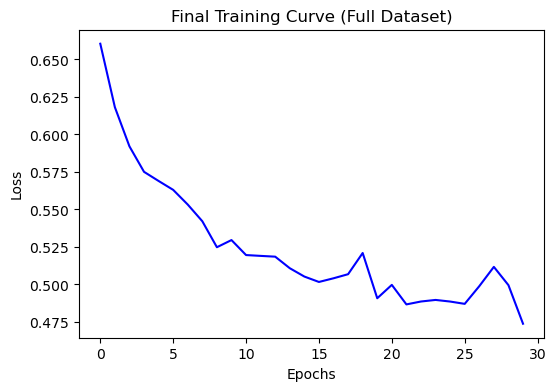

Model saved as 'resnet50_final_model.pth'


In [17]:
POCHS = 30  # Vul hier jouw beste aantal in
LEARNING_RATE = 1e-3  # Vul hier jouw beste LR in

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_final.parameters(), lr=LEARNING_RATE)
full_history = {"train_loss": []}


for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0

    for X, y in full_train_loader:
        X = X.to(device)
        y = y.to(device).float().unsqueeze(1)
        optimizer.zero_grad()
        logits = model_final(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(y)

    train_loss /= len(full_train_dataset)
    full_history["train_loss"].append(train_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

# Plot de curve
plt.figure(figsize=(6, 4))
plt.plot(full_history["train_loss"], color="blue")
plt.title("Final Training Curve (Full Dataset)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


torch.save(model_final.state_dict(), "resnet50_final_model.pth")
print("Model saved as 'resnet50_final_model.pth'")

In [18]:
model_reloaded = models.resnet50()
model_reloaded.fc = nn.Sequential(nn.Dropout(p=0.5), nn.Linear(num_features, 1))
model_reloaded.load_state_dict(
    torch.load("resnet50_final_model.pth", map_location=device)
)
model_reloaded = model_reloaded.to(device)
model_reloaded.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Finetuning the model

In [19]:
import copy

model_final.load_state_dict(torch.load("resnet50_final_model.pth", map_location=device))

# unfreeze
for param in model_final.parameters():
    param.requires_grad = True

FINE_TUNE_LR = 1e-4
EPOCHS = 30

optimizer_ft = optim.Adam(model_final.parameters(), lr=FINE_TUNE_LR)
criterion = nn.BCEWithLogitsLoss()

# back up
best_model_weights = copy.deepcopy(model_final.state_dict())
best_loss = float("inf")


full_history_ft = {"train_loss": []}

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0

    for X, y in full_train_loader:
        X = X.to(device)
        y = y.to(device).float().unsqueeze(1)

        optimizer_ft.zero_grad()
        loss = criterion(model_final(X), y)
        loss.backward()
        optimizer_ft.step()

        train_loss += loss.item() * len(y)

    train_loss /= len(full_train_dataset)
    full_history_ft["train_loss"].append(train_loss)
    print(f"Fine-tune Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

    if train_loss < best_loss:
        best_loss = train_loss
        best_model_weights = copy.deepcopy(model_final.state_dict())

Fine-tune Epoch 01/30 | Train Loss: 0.4130
Fine-tune Epoch 02/30 | Train Loss: 0.3076
Fine-tune Epoch 03/30 | Train Loss: 0.2077
Fine-tune Epoch 04/30 | Train Loss: 0.1846
Fine-tune Epoch 05/30 | Train Loss: 0.1390
Fine-tune Epoch 06/30 | Train Loss: 0.1165
Fine-tune Epoch 07/30 | Train Loss: 0.0977
Fine-tune Epoch 08/30 | Train Loss: 0.1032
Fine-tune Epoch 09/30 | Train Loss: 0.0928
Fine-tune Epoch 10/30 | Train Loss: 0.0752
Fine-tune Epoch 11/30 | Train Loss: 0.0490
Fine-tune Epoch 12/30 | Train Loss: 0.0659
Fine-tune Epoch 13/30 | Train Loss: 0.0649
Fine-tune Epoch 14/30 | Train Loss: 0.0513
Fine-tune Epoch 15/30 | Train Loss: 0.0341
Fine-tune Epoch 16/30 | Train Loss: 0.0313
Fine-tune Epoch 17/30 | Train Loss: 0.0349
Fine-tune Epoch 18/30 | Train Loss: 0.0401
Fine-tune Epoch 19/30 | Train Loss: 0.0326
Fine-tune Epoch 20/30 | Train Loss: 0.0525
Fine-tune Epoch 21/30 | Train Loss: 0.0279
Fine-tune Epoch 22/30 | Train Loss: 0.0462
Fine-tune Epoch 23/30 | Train Loss: 0.0279
Fine-tune E

In [20]:
model_final.load_state_dict(best_model_weights)
torch.save(model_final.state_dict(), "resnet50_finetuned_best.pth")
print(" Fine-tuning compleet and best model saved!")

 Fine-tuning compleet and best model saved!



--- TEST RESULTATEN ---
Precision: 0.9388
Recall:    0.9200
F1-score:  0.9293
AUC (ROC): 0.9938


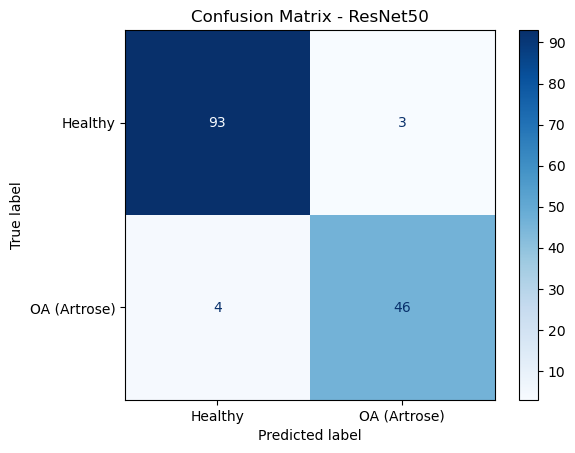

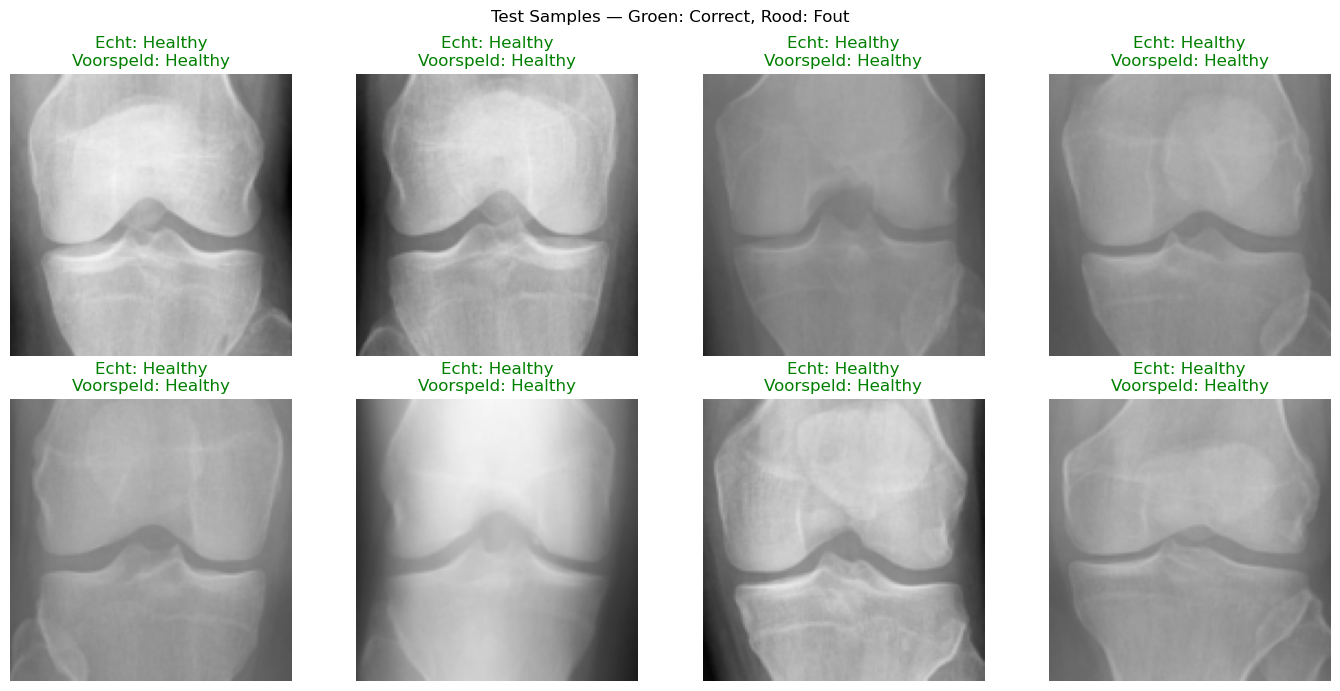

In [21]:
model_final.eval()
test_probs, test_preds, test_labels = [], [], []
test_samples = []

with torch.no_grad():
    for X, y in test_loader:
        X_device = X.to(device)
        logits = model_final(X_device)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        test_probs.extend(probs)
        test_preds.extend(preds)
        test_labels.extend(y.numpy())

        if len(test_samples) < 8:
            for i in range(len(X)):
                if len(test_samples) < 8:
                    test_samples.append((X[i], y[i].item(), preds[i].item()))

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

# 3. Print the performance metrics
metrics = calculate_metrics(test_loader, model_final)
print("\n--- TEST RESULTATEN ---")
# print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1-score:  {metrics['f1']:.4f}")
print(f"AUC (ROC): {metrics['auc']:.4f}")


# 4. Display the confusion matrix
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Healthy", "OA (Artrose)"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - ResNet50")
plt.show()


# 5. Plot a few samples with predictions
def denormalize_3channel(tensor):
    mean = torch.tensor([train_mean, train_mean, train_mean]).view(3, 1, 1)
    std = torch.tensor([train_std, train_std, train_std]).view(3, 1, 1)
    return tensor * std + mean


class_names = ["Healthy", "OA"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (img_tensor, true_label, pred_label) in zip(axes.flat, test_samples):
    img_display = denormalize_3channel(img_tensor).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)

    ax.imshow(img_display)

    color = "green" if true_label == pred_label else "red"
    ax.set_title(
        f"Echt: {class_names[int(true_label)]}\nVoorspeld: {class_names[int(pred_label)]}",
        color=color,
    )
    ax.axis("off")

plt.suptitle("Test Samples — Groen: Correct, Rood: Fout")
plt.tight_layout()
plt.show()

##### How did you choose the architecture for the final layers you added to the pretrained model?

We replaced the original final layer (which was initially designed for 1000 ImageNet categories) with a nn.Sequential block. This new classification head consists of a dropout layer (p=0.5) and a Linear (fully connected) layer with 1 output. We choose one output because we need a binary classification (healthy/artrose). To optimize this, we used the BCEWithLogitsLoss function, which maps this raw output into a probability score. 

Furthermore, the Dropout layer was necessary to prevent overfitting. ResNet50 is a big architecture and the 2048 feature pathways emerging from its base layers cotain a vast amount of information. Because our medical datasets are (relatively) small, there was a risk of overfitting. By randomely deactivating 50% of the neruons during training, we forced the network to develop more robust feature representations rather than relying to much on any single specific neural pathway.

##### How did the pretrained model’s training curve compare to the final baseline model?

When comparing the training curve of the baseline model to our pretrained ResNet50 model, a significant difference in starting point and scale is visible. The baseline model started with a very high training loss (around 2.8) and had a big initial drop to learn the most basic visual patterns. In contrast, the pretrained ResNet50 model started at a much lower loss (around 0.65) because it already possessed nessecary knowledge of shapes and textures form the ImageNet dataset. Altough it looks like the ResNet curve flutuates more, analyzing the Y-axis reveals that these changes are very small (fluctuating by fractions of 0.02) compared to the broad scale of the baseline model. This indicates a higher stability.

Ultimately, while the baseline stagnated around a loss of 0.4, the ResNet model was able to lower the loss down to 0.01 during the final fine-tuning phase. This results in a better final performance.(AUC: 0.987)

##### Describe any hyperparameters you changed or further fine-tuning you performed

During the initial training of the newly added classification head, we tried multiple learning rates. Here we observed that an learning rate of 1e-3 was the most stable and optimal. We also changed the amount of epochs, were the best results were observed around 30.

When we unfroze the entire model to fine-tune the base layers, it was important to lower the learning rate to 1e-4. This small step size was necessary to prevent "forgetting", ensuring we did not destroy the valuable pre-trained ImageNet weights while the model adapted to the specific noise patterns of the X-ray data.

To make sure we captured the optimal state of the network, we implemented a tracking mechanism (copy.deepcopy) that monitored the model's performance after every epoch. Although the final fine-tuning run was set for 30 epochs, the model reached its absolute peak of mathematical performance around the 20th epoch. The weights from this point were saved as our definitive final model, preventing any potential overfitting in the later epochs.



##### Discuss, based on this experience, the advantages and disadvantages of this approach.

Based on this ecperience, we identified several benefits and challenges associated with this approach. 

+ (+) Even with a relatively small dataset, we achieved really good results (F1 = 0.95). This was possible because we could use the extensive feature-extraction capabalities the model has from processing millions of images in the ImageNet dataset.

+ (+) Because the pre-trained model already understood basic visual features (e.g. edges, shapes, textures, ...), it did not have to learn these from scratch. As a result, we achieved an exceptionally high AUC in a relatively short amount of time (30 epochs).

- (-) In the medical field it is necessary that the results are "easy" to be interpreted. Docters need to understand why an AI diagnoses a patient with osteoarthitis. While a relatively simple baseline model with only a few layers offers some transparency, a deep and complex architecture like ResNet50 opereates like a "black box". This makes it very difficult for humans to find the exact reasoning behind its predictions.

- (-) The model consists of millions of parameters. Training and especially fine-tuning this architecture is resource intesive. It demands significant RAM and GPU (or CPU) capabilties. This became particularly apparent when combining the training and validations sets. When doing so, trainingt the model took around 35 minutes with a CPU.

- (-) ResNet50 is normally designed for  3-channel RGB color images. This was different from our baseline model. To prevent input errors, we had to duplicate our single-channel grayscale X-rays across three channels (with transfroms.Grayscale(num_outut_channels=3)).